In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
btc_raw = pd.read_csv("BTC_full_data.csv")
eth_raw = pd.read_csv("ETH_full_data.csv")

In [18]:
btc = btc_raw.copy()
btc["Date"] = pd.to_datetime(btc["Date"])
btc = btc.sort_values("Date").reset_index(drop=True)

def add_macd(data, a=12, b=26, c=9, price_col="Close"):
    out = data.copy()

    if a >= b:
        raise ValueError("Need a < b for MACD.")

    out["ema_fast"] = out[price_col].ewm(span=a, adjust=False).mean()
    out["ema_slow"] = out[price_col].ewm(span=b, adjust=False).mean()
    out["macd"] = out["ema_fast"] - out["ema_slow"]
    out["signal"] = out["macd"].ewm(span=c, adjust=False).mean()
    out["hist"] = out["macd"] - out["signal"]

    return out

def make_position(macd, signal, mode="long_flat", buffer=0.0):
    spread = macd - signal

    if mode == "long_flat":
        # bullish -> long, else flat
        pos = np.where(spread > buffer, 1, 0)

    elif mode == "long_short":
        # bullish -> long, bearish -> short, no flat
        pos = np.where(spread > buffer, 1, -1)

    elif mode == "long_short_flat":
        # bullish -> long, bearish -> short, weak signal -> flat
        pos = np.where(
            spread > buffer, 1,
            np.where(spread < -buffer, -1, 0)
        )

    else:
        raise ValueError("mode must be 'long_flat', 'long_short', or 'long_short_flat'")

    return pd.Series(pos, index=macd.index)

def backtest_macd(
    data,
    a=12,
    b=26,
    c=9,
    mode="long_flat",
    buffer=0.0,
    fee=0.0,
    price_col="Close",
    rf_annual=0.03
):
    out = add_macd(data, a=a, b=b, c=c, price_col=price_col)

    out["ret"] = out[price_col].pct_change().fillna(0)

    raw_pos = make_position(
        out["macd"],
        out["signal"],
        mode=mode,
        buffer=buffer
    )

    # shift by 1 day to avoid look-ahead bias
    out["position"] = raw_pos.shift(1).fillna(0)

    # turnover
    out["trade"] = out["position"].diff().abs().fillna(0)

    # daily pnl / return
    out["daily_pnl"] = out["position"] * out["ret"] - out["trade"] * fee

    # equity / cumulative pnl
    out["equity_curve"] = (1 + out["daily_pnl"]).cumprod()
    out["cumulative_pnl"] = out["equity_curve"] - 1

    # drawdown
    out["running_max"] = out["equity_curve"].cummax()
    out["drawdown"] = out["equity_curve"] / out["running_max"] - 1

    # metrics
    n = len(out)
    years = n / 365.25

    cumulative_pnl = out["cumulative_pnl"].iloc[-1]
    average_daily_pnl = out["daily_pnl"].mean()
    max_drawdown = out["drawdown"].min()
    annualised_return = out["equity_curve"].iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan

    daily_std = out["daily_pnl"].std()
    annualised_vol = daily_std * np.sqrt(365)

    rf_daily = (1 + rf_annual) ** (1 / 365) - 1
    excess_daily = out["daily_pnl"] - rf_daily
    sharpe_ratio = (excess_daily.mean() / daily_std) * np.sqrt(365) if daily_std > 0 else np.nan

    summary = {
        "mode": mode,
        "buffer": buffer,
        "a": a,
        "b": b,
        "c": c,
        "cumulative_pnl": cumulative_pnl,
        "average_daily_pnl": average_daily_pnl,
        "max_drawdown": max_drawdown,
        "annualised_return": annualised_return,
        "sharpe_ratio_rf_3pct": sharpe_ratio,
        "daily_std_dev": daily_std,
        "annualised_volatility": annualised_vol,
    }

    return out, summary

In [24]:
configs = [
    {"mode": "long_flat", "buffer": 0.0},
    {"mode": "long_short", "buffer": 0.0},
    {"mode": "long_short_flat", "buffer": 0.0},
    {"mode": "long_short_flat", "buffer": 25.0},
    {"mode": "long_short_flat", "buffer": 50.0},
]

all_results = []

for cfg in configs:
    bt, summary = backtest_macd(
        btc,
        a=12,
        b=26,
        c=9,
        mode=cfg["mode"],
        buffer=cfg["buffer"],
        fee=0.0,
        price_col="Close"
    )
    all_results.append(summary)

results_df = pd.DataFrame(all_results)
print(results_df)

              mode  buffer   a   b  c  cumulative_pnl  average_daily_pnl  \
0        long_flat     0.0  12  26  9       11.115217           0.001115   
1       long_short     0.0  12  26  9        2.635127           0.001009   
2  long_short_flat     0.0  12  26  9        3.025661           0.001043   
3  long_short_flat    25.0  12  26  9        3.476380           0.001031   
4  long_short_flat    50.0  12  26  9        1.741920           0.000814   

   max_drawdown  annualised_return  sharpe_ratio_rf_3pct  daily_std_dev  \
0     -0.487110           0.366038              0.860350       0.022966   
1     -0.599567           0.175138              0.523402       0.033891   
2     -0.599567           0.190229              0.542903       0.033842   
3     -0.667597           0.206129              0.560336       0.032398   
4     -0.670867           0.134424              0.454269       0.030847   

   annualised_volatility  
0               0.438761  
1               0.647484  
2          

In [26]:
a_values = [6, 8, 10, 12, 15, 18]
b_values = [20, 26, 30, 35, 40, 50]
c_values = [5, 7, 9, 12, 15]

all_results = []

for a in a_values:
    for b in b_values:
        if a >= b:
            continue
        for c in c_values:
            bt, summary = backtest_macd(
                btc,
                a=a,
                b=b,
                c=c,
                mode="long_flat",   # best mode from your earlier test
                buffer=0.0,
                fee=0.0,
                price_col="Close",
                rf_annual=0.03
            )
            all_results.append(summary)

results_df = pd.DataFrame(all_results)

# Sort by Sharpe first, then annualised return
results_sorted = results_df.sort_values(
    ["sharpe_ratio_rf_3pct", "annualised_return"],
    ascending=False
).reset_index(drop=True)

print(results_sorted.head(20).round(4))

         mode  buffer   a   b   c  cumulative_pnl  average_daily_pnl  \
0   long_flat     0.0  15  20  15         19.4909             0.0013   
1   long_flat     0.0  18  20  15         19.2612             0.0013   
2   long_flat     0.0  18  20  12         18.9082             0.0013   
3   long_flat     0.0  15  50   5         15.4709             0.0012   
4   long_flat     0.0  12  26  15         16.0508             0.0012   
5   long_flat     0.0  15  26  12         16.0508             0.0012   
6   long_flat     0.0  12  30  12         15.4337             0.0012   
7   long_flat     0.0  18  26   9         15.4001             0.0012   
8   long_flat     0.0  18  26  12         15.3566             0.0012   
9   long_flat     0.0  15  26  15         15.1324             0.0012   
10  long_flat     0.0  15  40   5         14.4050             0.0012   
11  long_flat     0.0  12  50   7         14.1231             0.0012   
12  long_flat     0.0  15  50  15         14.0692             0.

In [13]:
best = top.iloc[0]
print(best)

best_bt, best_summary = backtest_macd(
    btc,
    a=int(best["a"]),
    b=int(best["b"]),
    c=int(best["c"]),
    fee=0.001,
    price_col="Close"
)

a                   15.000000
b                   26.000000
c                   12.000000
total_return        13.537142
cagr                 0.397525
sharpe               0.971253
max_drawdown        -0.597872
trades             159.000000
buy_hold_return      5.474983
buy_hold_cagr        0.263105
Name: 0, dtype: float64


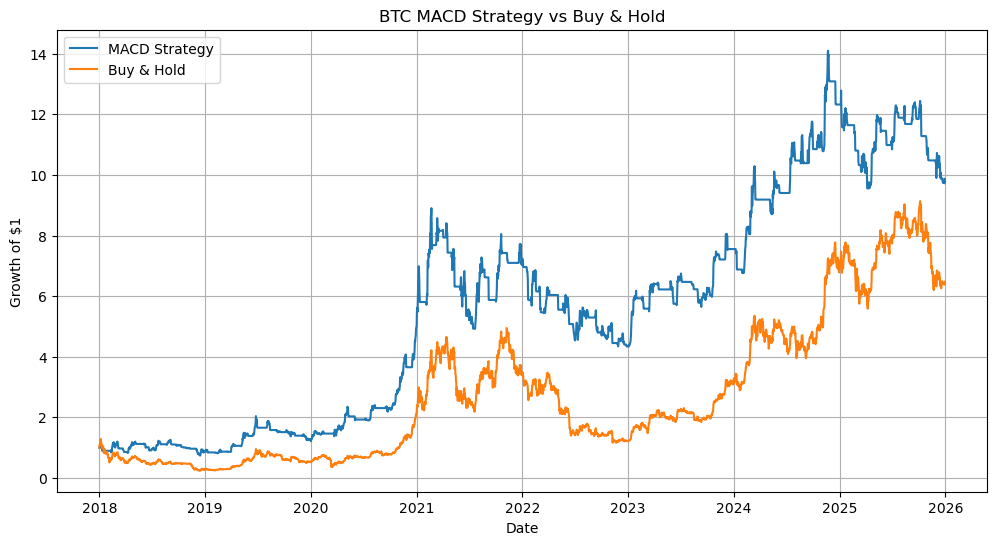

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(bt["Date"], bt["equity"], label="MACD Strategy")
plt.plot(bt["Date"], bt["buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("BTC MACD Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()